In [18]:
import pandas as pd
from torch.nn import functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset
import torch
from jax import grad, hessian
from scipy.optimize import minimize
from scipy.optimize import Bounds
df = pd.read_csv('airfoil_data.csv')

df = df.iloc[:,1:-4] # remove the name of airfoil as it is not useful to train NN.
df.iloc[:,3] = np.log(df.iloc[:,3])
df = df.dropna().copy()
df

,reynoldsNumber,alpha,coefficientLift,coefficientDrag,coefficientMoment,max_thickness,thickness_position,max_camber,camber_position,leading_edge_radius,...,thickness_x_0.8_y,camber_x_0.25_y,camber_x_0.5_y,camber_x_0.75_y,upper_slope_x_0.2_y,upper_slope_x_0.5_y,upper_slope_x_0.8_y,lower_slope_x_0.2_y,lower_slope_x_0.5_y,lower_slope_x_0.8_y
0,50000.0,-10.00,-0.3523,-2.212013,-0.0113,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
1,50000.0,-9.75,-0.5318,-2.516273,-0.0429,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
2,50000.0,-9.50,-0.6128,-2.596017,-0.0444,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
3,50000.0,-9.25,-0.6357,-2.668589,-0.0432,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
4,50000.0,-9.00,-0.6648,-2.724485,-0.0404,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463,1000000.0,5.00,0.8155,-4.422849,-0.0808,0.090896,0.351759,0.030268,0.592965,0.003158,...,0.046369,0.016287,0.02913,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3464,200000.0,-3.75,-0.2325,-4.020722,-0.0715,0.090896,0.351759,0.030268,0.592965,0.003158,...,0.046369,0.016287,0.02913,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3465,100000.0,-3.75,-0.3898,-3.846235,-0.0421,0.090896,0.351759,0.030268,0.592965,0.003158,...,0.046369,0.016287,0.02913,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3466,200000.0,4.50,0.7836,-4.388447,-0.0837,0.090896,0.351759,0.030268,0.592965,0.003158,...,0.046369,0.016287,0.02913,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623


In [19]:
df_target = df.iloc[:,2:5]
df_x = pd.concat([df.iloc[:,0:2], df.iloc[:,7:-5]], axis=1)
df

,reynoldsNumber,alpha,coefficientLift,coefficientDrag,coefficientMoment,max_thickness,thickness_position,max_camber,camber_position,leading_edge_radius,...,thickness_x_0.8_y,camber_x_0.25_y,camber_x_0.5_y,camber_x_0.75_y,upper_slope_x_0.2_y,upper_slope_x_0.5_y,upper_slope_x_0.8_y,lower_slope_x_0.2_y,lower_slope_x_0.5_y,lower_slope_x_0.8_y
0,50000.0,-10.00,-0.3523,-2.212013,-0.0113,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
1,50000.0,-9.75,-0.5318,-2.516273,-0.0429,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
2,50000.0,-9.50,-0.6128,-2.596017,-0.0444,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
3,50000.0,-9.25,-0.6357,-2.668589,-0.0432,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
4,50000.0,-9.00,-0.6648,-2.724485,-0.0404,0.154881,0.351759,0.015760,0.195980,0.020511,...,0.057539,0.015513,0.01290,0.007071,0.119900,-0.114600,-0.171600,-0.124700,0.085900,0.115400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3463,1000000.0,5.00,0.8155,-4.422849,-0.0808,0.090896,0.351759,0.030268,0.592965,0.003158,...,0.046369,0.016287,0.02913,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3464,200000.0,-3.75,-0.2325,-4.020722,-0.0715,0.090896,0.351759,0.030268,0.592965,0.003158,...,0.046369,0.016287,0.02913,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3465,100000.0,-3.75,-0.3898,-3.846235,-0.0421,0.090896,0.351759,0.030268,0.592965,0.003158,...,0.046369,0.016287,0.02913,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623
3466,200000.0,4.50,0.7836,-4.388447,-0.0837,0.090896,0.351759,0.030268,0.592965,0.003158,...,0.046369,0.016287,0.02913,0.025087,0.127835,-0.006183,-0.192771,0.037317,0.052462,0.024623


In [20]:
print(df_x.dtypes)
print(df_x.shape)

reynoldsNumber               float64
alpha                        float64
max_camber                   float64
camber_position              float64
leading_edge_radius          float64
trailing_edge_angle_deg_y    float64
thickness_x_0.2_y            float64
thickness_x_0.4_y            float64
thickness_x_0.6_y            float64
thickness_x_0.8_y            float64
camber_x_0.25_y              float64
camber_x_0.5_y               float64
camber_x_0.75_y              float64
upper_slope_x_0.2_y          float64
dtype: object
(3433, 14)


In [21]:
print(df.isna().sum())

reynoldsNumber               0
alpha                        0
coefficientLift              0
coefficientDrag              0
coefficientMoment            0
max_thickness                0
thickness_position           0
max_camber                   0
camber_position              0
leading_edge_radius          0
trailing_edge_angle_deg_y    0
thickness_x_0.2_y            0
thickness_x_0.4_y            0
thickness_x_0.6_y            0
thickness_x_0.8_y            0
camber_x_0.25_y              0
camber_x_0.5_y               0
camber_x_0.75_y              0
upper_slope_x_0.2_y          0
upper_slope_x_0.5_y          0
upper_slope_x_0.8_y          0
lower_slope_x_0.2_y          0
lower_slope_x_0.5_y          0
lower_slope_x_0.8_y          0
dtype: int64


In [22]:
df_target

,coefficientLift,coefficientDrag,coefficientMoment
0,-0.3523,-2.212013,-0.0113
1,-0.5318,-2.516273,-0.0429
2,-0.6128,-2.596017,-0.0444
3,-0.6357,-2.668589,-0.0432
4,-0.6648,-2.724485,-0.0404
...,...,...,...
3463,0.8155,-4.422849,-0.0808
3464,-0.2325,-4.020722,-0.0715
3465,-0.3898,-3.846235,-0.0421
3466,0.7836,-4.388447,-0.0837


In [23]:
from sklearn.model_selection import train_test_split

features = torch.tensor(df_x.values, dtype=torch.float32)
labels   = torch.tensor(df_target.values, dtype=torch.float32)

# 70 / 20 / 10  →  carve off 10% test, then 2/9 of the remainder = 20% val
X_tmp, X_test, y_tmp, y_test = train_test_split(
    features, labels, test_size=0.10, random_state=42)
X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    X_tmp, y_tmp, test_size=2/9, random_state=42)

# Normalise with TRAIN stats only
X_mean = X_train.mean(dim=0, keepdim=True)
X_std  = X_train.std(dim=0, keepdim=True)
y_mean = y_train_raw.mean(dim=0, keepdim=True)
y_std  = y_train_raw.std(dim=0, keepdim=True)

x_train = (X_train - X_mean) / X_std
y_train = (y_train_raw - y_mean) / y_std
x_val   = (X_val   - X_mean) / X_std
y_val   = (y_val_raw - y_mean) / y_std
x_test_n = (X_test  - X_mean) / X_std
y_test_n = (y_test  - y_mean) / y_std

print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test_n)}")

Train: 2402 | Val: 687 | Test: 344


Device: cuda
Searching 48 configurations...

[ 1/48] val=0.06264  {'lr': 0.001, 'wd': 0.0001, 'hidden': 64, 'dropout': 0.1, 'n_blocks': 2}  elapsed=   23s  eta= 1059s
[ 2/48] val=0.06301  {'lr': 0.001, 'wd': 0.0001, 'hidden': 64, 'dropout': 0.1, 'n_blocks': 3}  elapsed=   65s  eta= 1498s
[ 3/48] val=0.05988  {'lr': 0.001, 'wd': 0.0001, 'hidden': 64, 'dropout': 0.2, 'n_blocks': 2}  elapsed=   89s  eta= 1330s
[ 4/48] val=0.06370  {'lr': 0.001, 'wd': 0.0001, 'hidden': 64, 'dropout': 0.2, 'n_blocks': 3}  elapsed=  126s  eta= 1381s
[ 5/48] val=0.05663  {'lr': 0.001, 'wd': 0.0001, 'hidden': 128, 'dropout': 0.1, 'n_blocks': 2}  elapsed=  154s  eta= 1320s
[ 6/48] val=0.07178  {'lr': 0.001, 'wd': 0.0001, 'hidden': 128, 'dropout': 0.1, 'n_blocks': 3}  elapsed=  167s  eta= 1169s
[ 7/48] val=0.05837  {'lr': 0.001, 'wd': 0.0001, 'hidden': 128, 'dropout': 0.2, 'n_blocks': 2}  elapsed=  191s  eta= 1118s
[ 8/48] val=0.06015  {'lr': 0.001, 'wd': 0.0001, 'hidden': 128, 'dropout': 0.2, 'n_blocks': 3}  el

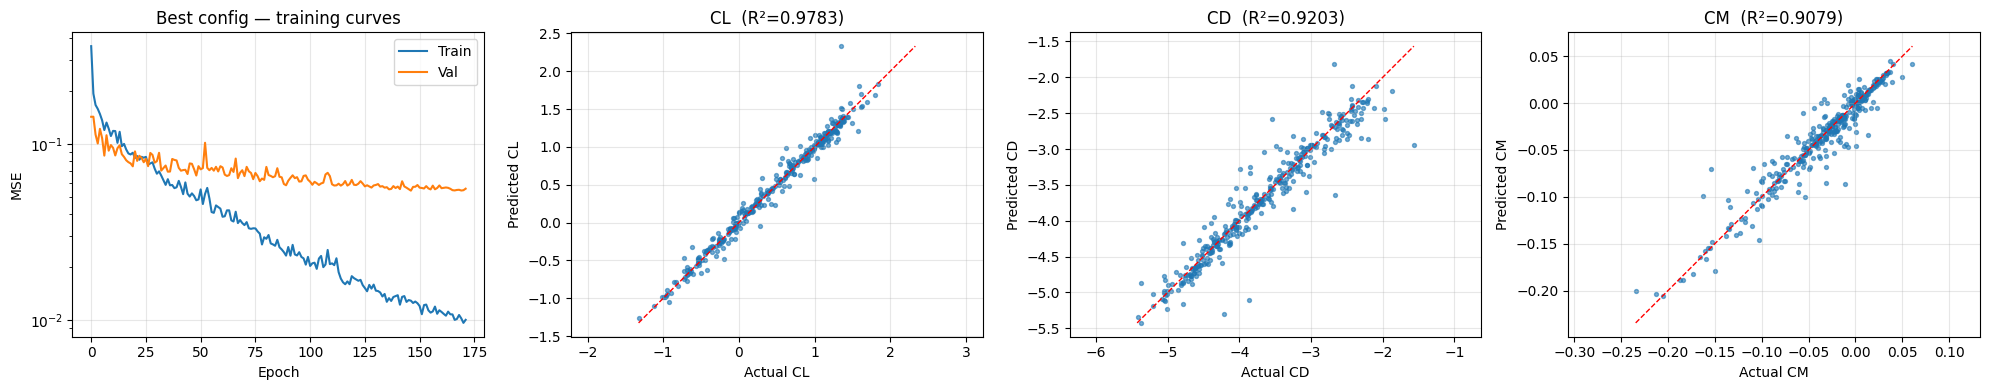

In [24]:
import itertools, time, copy
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
import matplotlib.pyplot as plt

# ── Parameterised model ──────────────────────────────────────────────────────
class AirfoilNet(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128, dropout=0.1, n_blocks=2):
        super().__init__()
        self.stem = nn.Sequential(nn.Linear(in_dim, hidden), nn.GELU())
        self.blocks = nn.ModuleList(
            [self._res_block(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, out_dim))

    @staticmethod
    def _res_block(dim, drop):
        return nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(drop),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(drop),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(),
        )

    def forward(self, x):
        h = self.stem(x)
        for blk in self.blocks:
            h = h + blk(h)
        return self.head(h)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Move data once
x_tr = x_train.to(device); y_tr = y_train.to(device)
x_va = x_val.to(device);   y_va = y_val.to(device)
x_te = x_test_n.to(device); y_te = y_test_n.to(device)

# ── HP grid (2 × 2 × 3 × 2 × 2 = 48 configs) ─────────────────────────────────
search_space = {
    'lr':       [1e-3, 3e-4],
    'wd':       [1e-4, 1e-3],
    'hidden':   [64, 128, 256],
    'dropout':  [0.1, 0.2],
    'n_blocks': [2, 3],
}

EPOCHS, PATIENCE, BATCH = 200, 25, 64

def train_one(cfg, return_history=False):
    torch.manual_seed(0)
    model = AirfoilNet(x_tr.shape[1], y_tr.shape[1],
                      hidden=cfg['hidden'], dropout=cfg['dropout'],
                      n_blocks=cfg['n_blocks']).to(device)
    opt = optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['wd'])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

    n = x_tr.shape[0]
    best_val, best_state, bad = float('inf'), None, 0
    tr_hist, va_hist = [], []
    for ep in range(EPOCHS):
        model.train()
        perm = torch.randperm(n, device=device)
        running = 0.0
        for i in range(0, n, BATCH):
            idx = perm[i:i+BATCH]
            pred = model(x_tr[idx])
            loss = F.mse_loss(pred, y_tr[idx])
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * idx.numel()
        sch.step()
        tr_mse = running / n
        model.eval()
        with torch.no_grad():
            v = F.mse_loss(model(x_va), y_va).item()
        tr_hist.append(tr_mse); va_hist.append(v)
        if v < best_val:
            best_val = v
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    model.load_state_dict(best_state)
    if return_history:
        return model, best_val, tr_hist, va_hist
    return model, best_val

# ── Search ───────────────────────────────────────────────────────────────────
keys   = list(search_space.keys())
combos = list(itertools.product(*[search_space[k] for k in keys]))
print(f"Searching {len(combos)} configurations...\n")

results = []
t0 = time.time()
for i, vals in enumerate(combos, 1):
    cfg = dict(zip(keys, vals))
    _, v = train_one(cfg)
    results.append((v, cfg))
    elapsed = time.time() - t0
    eta = elapsed / i * (len(combos) - i)
    print(f"[{i:>2}/{len(combos)}] val={v:.5f}  {cfg}  "
          f"elapsed={elapsed:5.0f}s  eta={eta:5.0f}s")

results.sort(key=lambda r: r[0])
print("\n── Top 5 configs ──")
for v, c in results[:5]:
    print(f"  val={v:.5f}  {c}")

best_cfg = results[0][1]
print(f"\nRetraining best with full history: {best_cfg}")
model, best_val, tr_hist, va_hist = train_one(best_cfg, return_history=True)

# ── Final test evaluation ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds_norm = model(x_te)
    preds   = preds_norm * y_std.to(device) + y_mean.to(device)
    actuals = y_te       * y_std.to(device) + y_mean.to(device)
    ss_res = ((actuals - preds) ** 2).sum(dim=0)
    ss_tot = ((actuals - actuals.mean(dim=0)) ** 2).sum(dim=0)
    r2 = (1 - ss_res / ss_tot).cpu().numpy()

names = ['CL', 'CD', 'CM']
print("\n── R² on TEST set (held-out 10%) ──")
for n, s in zip(names, r2):
    print(f"  {n}: {s:.4f}")
print(f"  mean: {r2.mean():.4f}")

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].semilogy(tr_hist, label='Train'); axes[0].semilogy(va_hist, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title('Best config — training curves'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

p, a = preds.cpu().numpy(), actuals.cpu().numpy()
for i, name in enumerate(names):
    ax = axes[i+1]
    ax.scatter(a[:, i], p[:, i], s=8, alpha=0.6)
    lims = [min(a[:, i].min(), p[:, i].min()),
            max(a[:, i].max(), p[:, i].max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'Actual {name}'); ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}  (R²={r2[i]:.4f})')
    ax.set_aspect('equal', adjustable='datalim'); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

Epoch    1 | Train 0.360346 | Val 0.142994 | LR 1.00e-03
Epoch   25 | Train 0.082249 | Val 0.079069 | LR 9.83e-04
Epoch   50 | Train 0.049673 | Val 0.070445 | LR 9.33e-04
Epoch   75 | Train 0.036669 | Val 0.065445 | LR 8.54e-04
Epoch  100 | Train 0.024346 | Val 0.062580 | LR 7.50e-04
Epoch  125 | Train 0.018046 | Val 0.058004 | LR 6.30e-04
Epoch  150 | Train 0.015804 | Val 0.057022 | LR 5.00e-04
Early stop @ epoch 170 (no val improvement for 40 epochs)

Best val MSE: 0.054863

── R² on TEST set (held-out 10%) ──
  CL: 0.9739
  CD: 0.9225
  CM: 0.9023
  mean: 0.9329


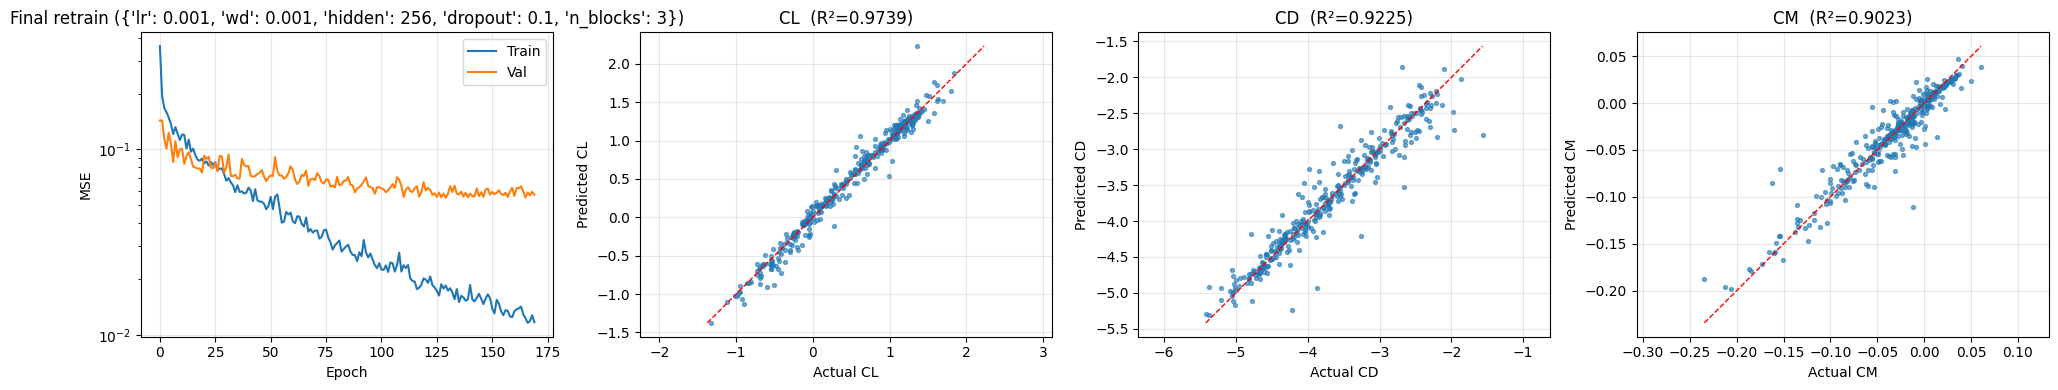

In [29]:
# Final retrain on best_cfg for 300 epochs
import copy
import torch.optim as optim
from torch.nn import functional as F

FINAL_EPOCHS, PATIENCE, BATCH = 300, 40, 64

torch.manual_seed(0)
model = AirfoilNet(x_tr.shape[1], y_tr.shape[1],
                   hidden=best_cfg['hidden'],
                   dropout=best_cfg['dropout'],
                   n_blocks=best_cfg['n_blocks']).to(device)
opt = optim.AdamW(model.parameters(), lr=best_cfg['lr'], weight_decay=best_cfg['wd'])
sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FINAL_EPOCHS, eta_min=1e-6)

n = x_tr.shape[0]
best_val, best_state, bad = float('inf'), None, 0
tr_hist, va_hist = [], []

for ep in range(1, FINAL_EPOCHS + 1):
    model.train()
    perm = torch.randperm(n, device=device)
    running = 0.0
    for i in range(0, n, BATCH):
        idx = perm[i:i+BATCH]
        loss = F.mse_loss(model(x_tr[idx]), y_tr[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item() * idx.numel()
    sch.step()
    tr_mse = running / n
    model.eval()
    with torch.no_grad():
        v = F.mse_loss(model(x_va), y_va).item()
    tr_hist.append(tr_mse); va_hist.append(v)
    if v < best_val:
        best_val = v
        best_state = copy.deepcopy(model.state_dict())
        bad = 0
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"Early stop @ epoch {ep} (no val improvement for {PATIENCE} epochs)")
            break
    if ep % 25 == 0 or ep == 1:
        print(f"Epoch {ep:4d} | Train {tr_mse:.6f} | Val {v:.6f} | LR {sch.get_last_lr()[0]:.2e}")

model.load_state_dict(best_state)
print(f"\nBest val MSE: {best_val:.6f}")

# ── Final test evaluation ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds_norm = model(x_te)
    preds   = preds_norm * y_std.to(device) + y_mean.to(device)
    actuals = y_te       * y_std.to(device) + y_mean.to(device)
    ss_res = ((actuals - preds) ** 2).sum(dim=0)
    ss_tot = ((actuals - actuals.mean(dim=0)) ** 2).sum(dim=0)
    r2 = (1 - ss_res / ss_tot).cpu().numpy()

names = ['CL', 'CD', 'CM']
print("\n── R² on TEST set (held-out 10%) ──")
for n_, s in zip(names, r2):
    print(f"  {n_}: {s:.4f}")
print(f"  mean: {r2.mean():.4f}")

# ── Plots ────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].semilogy(tr_hist, label='Train'); axes[0].semilogy(va_hist, label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title(f'Final retrain ({best_cfg})'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

p, a = preds.cpu().numpy(), actuals.cpu().numpy()
for i, name in enumerate(names):
    ax = axes[i+1]
    ax.scatter(a[:, i], p[:, i], s=8, alpha=0.6)
    lims = [min(a[:, i].min(), p[:, i].min()),
            max(a[:, i].max(), p[:, i].max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'Actual {name}'); ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name}  (R²={r2[i]:.4f})')
    ax.set_aspect('equal', adjustable='datalim'); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

In [25]:
# Save model + normalisation params
import torch, os

torch.save({
    "model_state_dict": model.state_dict(),
    "in_dim": x_train.shape[1],  # Use actual feature count (should be 21)
    "out_dim": y_train.shape[1],  # Should be 3
    "X_mean": X_mean.cpu(),
    "X_std":  X_std.cpu(),
    "y_mean": y_mean.cpu(),
    "y_std":  y_std.cpu(),
}, "airfoil_surrogate.pt")

print(f"Saved model with {x_train.shape[1]} input features and {y_train.shape[1]} output features.")


Saved model with 14 input features and 3 output features.


In [26]:
"""
nn_surrogate.py

"""

import numpy as np
import torch


def build_surrogate(model, X_mean, X_std, y_mean, y_std, device):
    """
    Returns (surrogate_fn, surrogate_grad, surrogate_fn_and_grad).

    Both accept a 1-D numpy array of physical design variables and
    return numpy scalars / arrays, so they slot straight into
    scipy.optimize or any other framework.
    """

    # ── freeze the network weights ──────────────────────────────────────
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    n_features = X_mean.shape[-1]


    xm = X_mean.to(device).squeeze()  
    xs = X_std.to(device).squeeze()
    ym = y_mean.to(device).squeeze()  
    ys = y_std.to(device).squeeze()

    def _to_normalised_tensor(x_phys):
        """Convert a 1-D numpy/list input to a normalised, grad-enabled tensor."""
        x_t = torch.tensor(np.asarray(x_phys, dtype=np.float32),
                           dtype=torch.float32, device=device)
        x_t = x_t.detach().requires_grad_(True)           # design variables need grad
        x_norm = (x_t - xm) / xs                          # z-score normalise
        return x_t, x_norm.unsqueeze(0)                    # add batch dim → (1, n_features)

    # ── helper: run model, denormalise, compute −CL/CD ──────────────────
    def _forward(x_phys):

        x_t, x_norm = _to_normalised_tensor(x_phys)
        y_norm = model(x_norm)                             # (1, 3) normalised
        y_phys = y_norm * ys + ym                          # de-normalise → (1, 3)

        cl     = y_phys[0, 0]
        log_cd = y_phys[0, 1]                              # the model predicts log(CD)
        cd     = torch.exp(log_cd)                         # convert to actual CD
        # small eps to avoid division by zero if CD ≈ 0
        obj = -(cl / (cd + 1e-8))
        return x_t, obj

    # ── public API ──────────────────────────────────────────────────────
    def surrogate_fn(x_phys):
        """Evaluate −CL/CD at a physical design point.  Returns a float."""
        with torch.enable_grad():
            _, obj = _forward(x_phys)
        return np.float64(obj.detach().cpu().item())

    def surrogate_grad(x_phys):
        """Gradient of −CL/CD w.r.t. the physical design variables.
        Returns a numpy array of shape (n_features,)."""
        with torch.enable_grad():
            x_t, obj = _forward(x_phys)
            obj.backward()
        return x_t.grad.detach().cpu().numpy().astype(np.float64)

    def surrogate_fn_and_grad(x_phys):
        """
        Convenience function that returns BOTH value and gradient in one
        forward+backward pass (more efficient than calling the two above
        separately).  Useful for scipy L-BFGS-B which wants jac=True.

        Returns
        -------
        val  : float
        grad : np.ndarray of shape (n_features,)
        """
        with torch.enable_grad():
            x_t, obj = _forward(x_phys)
            obj.backward()
        return np.float64(obj.detach().cpu().item()), x_t.grad.detach().cpu().numpy().astype(np.float64)

    return surrogate_fn, surrogate_grad, surrogate_fn_and_grad



In [27]:
'''x0=thickness
x1=thickness position
x2=max camber
x3=camber position
x4=leading edge radius
x5=trailing edge angle
x6=thickness@0.2
x7=thickness@0.4
x8=thickness@0.6
x9=thickness@0.8
x10=camber@0.25
x11=camber@0.5
x12=camber@0.75
x13=Reynolds Number
x14=AoA
'''
"""
c1 = lambda x: x[...,0]-0.042709509
c2 = lambda x: 0.299811795-x[...,0]
c3 = lambda x: x[...,1]-0.075376884
c4 = lambda x: 0.59798995-x[...,1]
c5 = lambda x: x[...,2]
c6 = lambda x: 0.102038677-x[...,2]
c7 = lambda x: x[...,3]
c8 = lambda x: 0.949748744-x[...,3]
c9 = lambda x: x[...,4]-0.000566528
c10 = lambda x: 0.153298667-x[...,4]
c11 = lambda x: x[...,5]-3.323935791
c12 = lambda x: 32.0659485-x[...,5]
c13 = lambda x: x[...,6]-0.035474776
c14 = lambda x: 0.287261418-x[...,6]
c15 = lambda x: x[...,7]-0.035474776
c16 = lambda x: 0.284575973-x[...,7]
c17 = lambda x: x[...,8]-0.023717899
c18 = lambda x: 0.114855638-x[...,8]
c19 = lambda x: x[...,9]-0.013386753
c20 = lambda x: 0.14678794-x[...,9]
c21 = lambda x: x[...,10]+0.003550395
c22 = lambda x: 0.090613329-x[...,10]
c23 = lambda x: x[...,11]+0.006245401
c24 = lambda x: 0.10187034-x[...,11]
c25 = lambda x: x[...,12]+0.008133774
c26 = lambda x: 0.074040277-x[...,12]
c27 = lambda x: x[...,13]-999999
c28 = lambda x: 1000001-x[...,13]
c29 = lambda x: x[...,14]-9.9
c30 = lambda x: 10.1-x[...,14]

ineq_con1 = {'type': 'ineq','fun': c1}
ineq_con2 = {'type': 'ineq','fun': c2}
ineq_con3 = {'type': 'ineq','fun': c3}
ineq_con4 = {'type': 'ineq','fun': c4}
ineq_con5 = {'type': 'ineq','fun': c5}
ineq_con6 = {'type': 'ineq','fun': c6}
ineq_con7 = {'type': 'ineq','fun': c7}
ineq_con8 = {'type': 'ineq','fun': c8}
ineq_con9 = {'type': 'ineq','fun': c9}
ineq_con10 = {'type': 'ineq','fun': c10}
ineq_con11 = {'type': 'ineq','fun': c11}
ineq_con12 = {'type': 'ineq','fun': c12}
ineq_con13 = {'type': 'ineq','fun': c13}
ineq_con14 = {'type': 'ineq','fun': c14}
ineq_con15 = {'type': 'ineq','fun': c15}
ineq_con16 = {'type': 'ineq','fun': c16}
ineq_con17 = {'type': 'ineq','fun': c17}
ineq_con18 = {'type': 'ineq','fun': c18}
ineq_con19 = {'type': 'ineq','fun': c19}
ineq_con20 = {'type': 'ineq','fun': c20}
ineq_con21 = {'type': 'ineq','fun': c21}
ineq_con22 = {'type': 'ineq','fun': c22}
ineq_con23 = {'type': 'ineq','fun': c23}
ineq_con24 = {'type': 'ineq','fun': c24}
ineq_con25 = {'type': 'ineq','fun': c25}
ineq_con26 = {'type': 'ineq','fun': c26}
ineq_con27 = {'type': 'ineq','fun': c27}
ineq_con28 = {'type': 'ineq','fun': c28}
ineq_con29 = {'type': 'ineq','fun': c29}
ineq_con30 = {'type': 'ineq','fun': c30}"""


"\nc1 = lambda x: x[...,0]-0.042709509\nc2 = lambda x: 0.299811795-x[...,0]\nc3 = lambda x: x[...,1]-0.075376884\nc4 = lambda x: 0.59798995-x[...,1]\nc5 = lambda x: x[...,2]\nc6 = lambda x: 0.102038677-x[...,2]\nc7 = lambda x: x[...,3]\nc8 = lambda x: 0.949748744-x[...,3]\nc9 = lambda x: x[...,4]-0.000566528\nc10 = lambda x: 0.153298667-x[...,4]\nc11 = lambda x: x[...,5]-3.323935791\nc12 = lambda x: 32.0659485-x[...,5]\nc13 = lambda x: x[...,6]-0.035474776\nc14 = lambda x: 0.287261418-x[...,6]\nc15 = lambda x: x[...,7]-0.035474776\nc16 = lambda x: 0.284575973-x[...,7]\nc17 = lambda x: x[...,8]-0.023717899\nc18 = lambda x: 0.114855638-x[...,8]\nc19 = lambda x: x[...,9]-0.013386753\nc20 = lambda x: 0.14678794-x[...,9]\nc21 = lambda x: x[...,10]+0.003550395\nc22 = lambda x: 0.090613329-x[...,10]\nc23 = lambda x: x[...,11]+0.006245401\nc24 = lambda x: 0.10187034-x[...,11]\nc25 = lambda x: x[...,12]+0.008133774\nc26 = lambda x: 0.074040277-x[...,12]\nc27 = lambda x: x[...,13]-999999\nc28 = 

In [28]:
# Step 1: Load the model and build surrogate
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load("airfoil_surrogate.pt", map_location=device, weights_only=True)

# Rebuild model
model = AirfoilNet(in_dim=ckpt["in_dim"], out_dim=ckpt["out_dim"]).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

X_mean = ckpt["X_mean"].to(device)
X_std  = ckpt["X_std"].to(device)
y_mean = ckpt["y_mean"].to(device)
y_std  = ckpt["y_std"].to(device)

# Build surrogate functions
surrogate_fn, surrogate_grad, surrogate_fn_and_grad = build_surrogate(model, X_mean, X_std, y_mean, y_std, device)
print("Model loaded and surrogate built")

# Step 2: Extract bounds from constraints and compute x0 as midpoint
# Bounds extracted from constraint definitions:
# (lower_bound, upper_bound) for each variable
bounds_dict = {
    0: (0.042709509, 0.299811795),           # x0: thickness
    1: (0.075376884, 0.59798995),            # x1: thickness position
    2: (0.0, 0.102038677),                   # x2: max camber
    3: (0.0, 0.949748744),                   # x3: camber position
    4: (0.000566528, 0.153298667),           # x4: leading edge radius
    5: (3.323935791, 32.0659485),            # x5: trailing edge angle
    6: (0.035474776, 0.287261418),           # x6: thickness@0.2
    7: (0.035474776, 0.284575973),           # x7: thickness@0.4
    8: (0.023717899, 0.114855638),           # x8: thickness@0.6
    9: (0.013386753, 0.14678794),            # x9: thickness@0.8
    10: (-0.003550395, 0.090613329),         # x10: camber@0.25
    11: (-0.006245401, 0.10187034),          # x11: camber@0.5
    12: (-0.008133774, 0.074040277),         # x12: camber@0.75
    13: (-0.009485666, 0.363013699),     # x13: upper slope@0.2 min
    14: (-0.347770701, 0.0089),    # x14: upper slope@0.5 min
    15: (-0.395454656,-0.02608302),     # x15: upper slope@0.8 min
    16: (-0.165354197, 0.199758113),     # x16: lower slope@0.2 min
    17: (-0.0395, 0.255351682),          # x17: lower slope@0.5 min
    18: (-0.11677498,0.271116505),      # x18: lower slope@0.8 min
    19: (900000,1200000 ),                   # x19: Reynolds number
    20: (8.0, 12.0),                         # x20: AoA
}      

RuntimeError: Error(s) in loading state_dict for AirfoilNet:
	Unexpected key(s) in state_dict: "blocks.2.0.weight", "blocks.2.0.bias", "blocks.2.1.weight", "blocks.2.1.bias", "blocks.2.1.running_mean", "blocks.2.1.running_var", "blocks.2.1.num_batches_tracked", "blocks.2.4.weight", "blocks.2.4.bias", "blocks.2.5.weight", "blocks.2.5.bias", "blocks.2.5.running_mean", "blocks.2.5.running_var", "blocks.2.5.num_batches_tracked", "blocks.2.8.weight", "blocks.2.8.bias", "blocks.2.9.weight", "blocks.2.9.bias", "blocks.2.9.running_mean", "blocks.2.9.running_var", "blocks.2.9.num_batches_tracked". 
	size mismatch for stem.0.weight: copying a param with shape torch.Size([256, 14]) from checkpoint, the shape in current model is torch.Size([128, 14]).
	size mismatch for stem.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for blocks.0.0.weight: copying a param with shape torch.Size([256, 256]) from checkpoint, th

In [33]:
c1 = lambda x: x[...,0]-0.042709509   #Max thickness lower bounds
c2 = lambda x: 0.154881457-x[...,0]   #Max thickness upper bound, kc135 max thickness

c3 = lambda x: x[...,1]-0.042518041   
c4 = lambda x: 0.154881457-x[...,1]   #Thickness@0.2

c5 = lambda x: x[...,2]-0.035474776
c6 = lambda x: 0.154881457-x[...,2]   #Thickness@0.4

c7 = lambda x: x[...,3]-0.023717899
c8 = lambda x: 0.154881457-x[...,3]   #Thickness@0.6

c9 = lambda x: x[...,4]-0.013386753
c10 = lambda x: 0.154881457-x[...,4]   #Thickness@0.8

#c11 = lambda x: x[...,5]-999999 
#c12 = lambda x: 1000001-x[...,5]      #Reynolds Number

#c13 = lambda x: x[...,6]-9.9
#c14 = lambda x: 10.1-x[...,6]    #AoA

ineq_con1 = {'type': 'ineq','fun': c1}
ineq_con2 = {'type': 'ineq','fun': c2}
ineq_con3 = {'type': 'ineq','fun': c3}
ineq_con4 = {'type': 'ineq','fun': c4}
ineq_con5 = {'type': 'ineq','fun': c5}
ineq_con6 = {'type': 'ineq','fun': c6}
ineq_con7 = {'type': 'ineq','fun': c7}
ineq_con8 = {'type': 'ineq','fun': c8}
ineq_con9 = {'type': 'ineq','fun': c9}
ineq_con10 = {'type': 'ineq','fun': c10}
#ineq_con11 = {'type': 'ineq','fun': c11}
#ineq_con12 = {'type': 'ineq','fun': c12}
#ineq_con13 = {'type': 'ineq','fun': c13}
#ineq_con14 = {'type': 'ineq','fun': c14}

In [ ]:

# Compute x0 as midpoint of bounds
x0 = np.zeros(21)  # 21 features total
for dim, (lower, upper) in bounds_dict.items():
    x0[dim] = (lower + upper) / 2
   
print(x0)
res_SLSQP = minimize(
    surrogate_fn,           # Use the objective function directly
    x0, 
    method='SLSQP',
    jac=surrogate_grad,     # Use the gradient function directly,
    constraints=[ineq_con1, ineq_con2, ineq_con3, ineq_con4, ineq_con5, ineq_con6, ineq_con7, ineq_con8, ineq_con9, ineq_con10],
    options={'ftol': 1e-9, 'disp': True, 'maxiter': 1000}
)

print(f"\n✓ Optimization complete!")
print(f"  Success: {res_SLSQP.success}")
print(f"  Optimal objective: {res_SLSQP.fun:.6f}")
print(f"  Initial objective: {surrogate_fn(x0):.6f}")
print(f"  Improvement: {surrogate_fn(x0) - res_SLSQP.fun:.6f}")
print(f"  Optimal design:\n{res_SLSQP.x}")

[ 1.14173768e-01  2.24455611e-01  3.40128923e-02  3.16582915e-01
  5.12883983e-02  1.17966281e+01  1.07578731e-01  1.06683583e-01
  4.61911790e-02  5.33915643e-02  2.90209780e-02  3.18749797e-02
  2.19688343e-02  1.17842678e-01 -1.12956900e-01 -1.40512559e-01
  1.14679720e-02  7.19505607e-02  5.14471750e-02  7.00000000e+05
  6.66666667e+00]
Inequality constraints incompatible    (Exit mode 4)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 1
            Gradient evaluations: 1

✓ Optimization complete!
  Success: False
  Optimal objective: 0.000000
  Initial objective: 0.000000
  Improvement: 0.000000
  Optimal design:
[ 1.14173768e-01  2.24455611e-01  3.40128923e-02  3.16582915e-01
  5.12883983e-02  1.17966281e+01  1.07578731e-01  1.06683583e-01
  4.61911790e-02  5.33915643e-02  2.90209780e-02  3.18749797e-02
  2.19688343e-02  1.17842678e-01 -1.12956900e-01 -1.40512559e-01
  1.14679720e-02  7.19505607e-02  5.14471750e-02  7.00000000e

In [ ]:
surrogate_fn(x0)

np.float64(0.0)

In [ ]:
print("\n" + "="*60)
print("COBYQA Optimization")
print("="*60)

# Better callback to track progress
iteration_data = {'iter': 0, 'best_f': np.inf, 'x_best': x0.copy()}

def callback_cobyqa(x):
    iteration_data['iter'] += 1
    f_val = surrogate_fn(x)
    
    # Check constraint violations
    ineq_viol = max([max(0, -con(x)) for con in [c1, c2, c3, c4, c5, c6, c7, c8, c9, c10, c11, c12, c13, c14, c15, c16, c17, c18, c19, c20, c21, c22, c23, c24, c25, c26, c27, c28, c29, c30]])
    
    if f_val < iteration_data['best_f']:
        iteration_data['best_f'] = f_val
        iteration_data['x_best'] = x.copy()
        marker = " ← BETTER"
    else:
        marker = ""
    
    if iteration_data['iter'] % 5 == 0 or iteration_data['iter'] <= 3:
        print(f"Iter {iteration_data['iter']:3d}: f={f_val:10.6f}  ineq_viol={ineq_viol:.2e}{marker}")

res_COBYQA = minimize(
    surrogate_fn,  # Use the objective function directly
    x0, 
    method='COBYQA',
    constraints=[
        ineq_con1, ineq_con2, ineq_con3, ineq_con4, ineq_con5, ineq_con6, ineq_con7, ineq_con8, ineq_con9, ineq_con10,
        ineq_con11, ineq_con12, ineq_con13, ineq_con14, ineq_con15, ineq_con16, ineq_con17, ineq_con18, ineq_con19, ineq_con20,
        ineq_con21, ineq_con22, ineq_con23, ineq_con24, ineq_con25, ineq_con26, ineq_con27, ineq_con28, ineq_con29, ineq_con30,
    ],
    options={'ftol': 1e-9, 'disp': True, 'maxiter': 1000},
    callback=callback_cobyqa
)

print(f"\n✓ Optimization complete!")
print(f"  Success: {res_COBYQA.success}")
print(f"  Best objective: {iteration_data['best_f']:.6f}")
print(f"  Initial objective: {surrogate_fn(x0):.6f}")
print(f"  Improvement: {surrogate_fn(x0) - iteration_data['best_f']:.6f}")
print(f"  Iterations: {iteration_data['iter']}")
print(f"  Optimal design:\n{res_COBYQA.x}")



COBYQA Optimization
Starting the optimization procedure.
Initial trust-region radius: 1.0.
Final trust-region radius: 1e-06.
Maximum number of function evaluations: 10500.
Maximum number of iterations: 1000.

surrogate_fn([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = -0.0
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 1.286e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 1.286e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 2.613e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 2.613e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 5.102e-02]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 5.102e-02]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 4.749e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 4.749e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 7.637e-02]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+

C:\Users\adity\AppData\Local\Temp\ipykernel_6640\3438802514.py:25: OptimizeWarning: Unknown solver options: ftol
  res_COBYQA = minimize(


surrogate_fn([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = -0.0
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 1.286e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 1.286e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 2.613e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 2.613e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 5.102e-02]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 5.102e-02]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 4.749e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 4.749e-01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 7.637e-02]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 7.637e-02]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 1.437e+01]
<lambda>([ 1.713e-01  3.367e-01 ...  0.000e+00  0.000e+00]) = [ 1.437e+01]
<lambda>([ 1.713e-01  3.367e-

In [ ]:
# Load model (skip retraining)
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load("airfoil_surrogate.pt", map_location=device, weights_only=True)

# Rebuild the model architecture (same as training cell) then load weights
model = AirfoilNet(in_dim=ckpt["in_dim"], out_dim=ckpt["out_dim"]).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

X_mean = ckpt["X_mean"].to(device)
X_std  = ckpt["X_std"].to(device)
y_mean = ckpt["y_mean"].to(device)
y_std  = ckpt["y_std"].to(device)

print("Loaded.")

Loaded.


In [ ]:
f, f_grad, _ =build_surrogate(model, X_mean, X_std, y_mean, y_std, device)

In [ ]:
bounds_dict = {
    0: (0.042709509, 0.299811795),           # x0: thickness
    1: (0.075376884, 0.59798995),            # x1: thickness position
    2: (0.0, 0.102038677),                   # x2: max camber
    3: (0.0, 0.949748744),                   # x3: camber position
    4: (0.000566528, 0.153298667),           # x4: leading edge radius
    5: (3.323935791, 32.0659485),            # x5: trailing edge angle
    6: (0.035474776, 0.287261418),           # x6: thickness@0.2
    7: (0.035474776, 0.284575973),           # x7: thickness@0.4
    8: (0.023717899, 0.114855638),           # x8: thickness@0.6
    9: (0.013386753, 0.14678794),            # x9: thickness@0.8
    10: (-0.003550395, 0.090613329),         # x10: camber@0.25
    11: (-0.006245401, 0.10187034),          # x11: camber@0.5
    12: (-0.008133774, 0.074040277),         # x12: camber@0.75
    13: (999999, 1000001),                   # x19: Reynolds number
    14: (9.9, 10.1),                         # x20: AoA
}

# Compute x0 as midpoint of bounds
x0 = np.zeros(15)  # 21 features total
for dim, (lower, upper) in bounds_dict.items():
    x0[dim] = (lower + upper) / 2

# For dimensions not explicitly bounded in constraints (13-18), use reasonable values
# These correspond to slope features, set them to small values

print(x0)

[1.71260652e-01 3.36683417e-01 5.10193385e-02 4.74874372e-01
 7.69325975e-02 1.76949421e+01 1.61368097e-01 1.60025374e-01
 6.92867685e-02 8.00873465e-02 4.35314670e-02 4.78124695e-02
 3.29532515e-02 1.00000000e+06 1.00000000e+01]


In [ ]:
x_phys = df_x.iloc[-2,:]
np.array(x0)

array([1.71260652e-01, 3.36683417e-01, 5.10193385e-02, 4.74874372e-01,
       7.69325975e-02, 1.76949421e+01, 1.61368097e-01, 1.60025374e-01,
       6.92867685e-02, 8.00873465e-02, 4.35314670e-02, 4.78124695e-02,
       3.29532515e-02, 1.00000000e+06, 1.00000000e+01])

In [40]:
neg_cl_cd = f(x0)

NameError: name 'f' is not defined

In [ ]:
log_cd = df_target.iloc[-2,1]
cd = np.exp(log_cd)
cl = df_target.iloc[-2,0]
actual_cl_cd = -cl/cd

In [ ]:
print(f"model accuracy to predict Cl over Cd is: {100 - np.abs(np.abs(actual_cl_cd) - np.abs(neg_cl_cd))/np.abs(actual_cl_cd)*100}%",)


model accuracy to predict Cl over Cd is: 94.26483574906682%
